# Vein Segmentation Training

Interactive notebook version of the training pipeline. Run cells top to bottom.

- **Architecture**: edit the model cells below (attention gates, CBAM head, channel widths, depth) and re-run.
- **Live progress**: the training loop cell redraws a loss/IoU chart after every epoch.
- **Data**: loads the pre-built tensors in `../segmentation_dataset/` (images.pt, masks.pt, meta.json), built by `build_dataset.py` from all 3 videos.


In [ ]:
import json, time, math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
from IPython.display import clear_output, display

%matplotlib inline

## 1. Config
Edit any of these and re-run the relevant cells below.

In [2]:
SEED = 42
DATA_DIR = Path("../segmentation_dataset")

BATCH_SIZE = 64
LR = 1e-3
WEIGHT_DECAY = 1e-4

TRAIN_TIME_BUDGET_MIN = 50.0   # hard wall-clock cap for the training loop
MAX_EPOCHS = 200               # secondary cap (whichever hits first)

OUT_DIR = Path("outputs_notebook")
OUT_DIR.mkdir(exist_ok=True)

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


device: cuda
GPU: NVIDIA GeForce RTX 5090


## 2. Load dataset tensors + train/val/test split

In [3]:
images = torch.load(DATA_DIR / "images.pt")   # uint8 [N,3,H,W]
masks  = torch.load(DATA_DIR / "masks.pt")    # uint8 [N,1,H,W]
with open(DATA_DIR / "meta.json") as f:
    meta = json.load(f)

print("images:", images.shape, images.dtype)
print("masks: ", masks.shape, masks.dtype)
print("total frames:", len(meta))
print("frames with a vein:", sum(m["has_vein"] for m in meta))


images: torch.Size([16645, 3, 256, 256]) torch.uint8
masks:  torch.Size([16645, 1, 256, 256]) torch.uint8
total frames: 16645
frames with a vein: 12461


In [4]:
n = len(meta)
idx = np.arange(n)
has_vein = np.array([m["has_vein"] for m in meta], dtype=np.int64)

train_idx, temp_idx, y_train, y_temp = train_test_split(
    idx, has_vein, test_size=0.2, random_state=SEED, stratify=has_vein)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, random_state=SEED, stratify=y_temp)

print(f"train/val/test sizes: {len(train_idx)} / {len(val_idx)} / {len(test_idx)}")


train/val/test sizes: 13316 / 1664 / 1665


In [6]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

class VeinSegDataset(Dataset):
    """Change augmentation logic here if you want."""
    def __init__(self, images, masks, indices, augment=False):
        self.images, self.masks, self.indices, self.augment = images, masks, indices, augment

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        img = self.images[idx].float() / 255.0
        mask = self.masks[idx].float() / 255.0

        if self.augment:
            if torch.rand(1).item() < 0.5:
                img = torch.flip(img, dims=[2])
                mask = torch.flip(mask, dims=[2])
            if torch.rand(1).item() < 0.3:
                factor = 0.8 + 0.4 * torch.rand(1).item()
                img = torch.clamp(img * factor, 0, 1)

        img = (img - IMAGENET_MEAN) / IMAGENET_STD
        mask = (mask > 0.5).float()
        return img, mask

train_ds = VeinSegDataset(images, masks, train_idx, augment=True)
val_ds   = VeinSegDataset(images, masks, val_idx, augment=False)
test_ds  = VeinSegDataset(images, masks, test_idx, augment=False)


## 3. Visualize a batch of examples

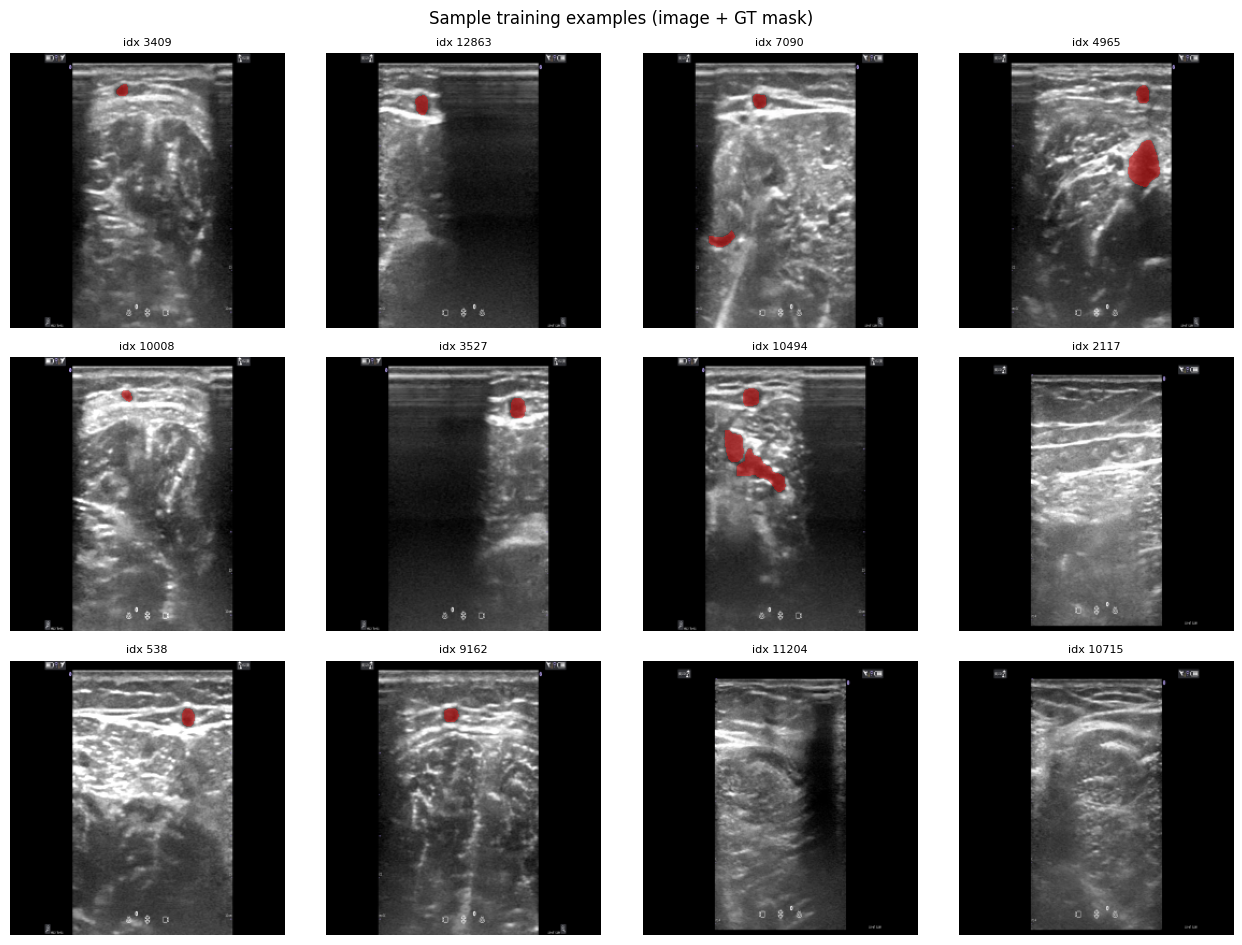

In [7]:
def denorm_img(img_tensor):
    img = img_tensor.cpu() * IMAGENET_STD + IMAGENET_MEAN
    return img.clamp(0, 1).permute(1, 2, 0).numpy()

def show_examples(dataset, n=12, title=""):
    idxs = np.random.choice(len(dataset), size=min(n, len(dataset)), replace=False)
    cols = 4
    rows = int(np.ceil(len(idxs) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.2, rows * 3.2))
    axes = np.array(axes).reshape(-1)
    for ax, i in zip(axes, idxs):
        img, mask = dataset[i]
        im = denorm_img(img)
        m = mask.squeeze(0).numpy()
        ax.imshow(im)
        ax.imshow(np.ma.masked_where(m == 0, m), cmap="autumn", alpha=0.45)
        ax.set_title(f"idx {i}", fontsize=8)
        ax.axis("off")
    for ax in axes[len(idxs):]:
        ax.axis("off")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

show_examples(train_ds, n=12, title="Sample training examples (image + GT mask)")


## 4. Model — Attention U-Net
Edit this cell to change the architecture:
- `base_ch` — width of the first encoder stage (doubles each stage)
- `use_attention_gates` — attention gates on the skip connections (Attention U-Net)
- `use_cbam_head` — channel+spatial attention (CBAM) applied right before the final 1x1 classification conv
- add/remove encoder/decoder stages for a deeper/shallower network


In [9]:
def conv_block(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
    )

class AttentionGate(nn.Module):
    """Gates skip-connection features `x` using the coarser decoder signal `g`."""
    def __init__(self, gate_ch, skip_ch, inter_ch):
        super().__init__()
        self.w_g = nn.Sequential(nn.Conv2d(gate_ch, inter_ch, 1), nn.BatchNorm2d(inter_ch))
        self.w_x = nn.Sequential(nn.Conv2d(skip_ch, inter_ch, 1), nn.BatchNorm2d(inter_ch))
        self.psi = nn.Sequential(nn.Conv2d(inter_ch, 1, 1), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        psi = self.relu(self.w_g(g) + self.w_x(x))
        return x * self.psi(psi)

class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 4)
        self.mlp = nn.Sequential(nn.Linear(channels, hidden), nn.ReLU(inplace=True), nn.Linear(hidden, channels))

    def forward(self, x):
        b, c, _, _ = x.shape
        avg = torch.mean(x, dim=(2, 3))
        mx, _ = torch.max(x.view(b, c, -1), dim=2)
        att = torch.sigmoid(self.mlp(avg) + self.mlp(mx)).view(b, c, 1, 1)
        return x * att

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        mx, _ = torch.max(x, dim=1, keepdim=True)
        return x * torch.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))

class CBAM(nn.Module):
    def __init__(self, channels, reduction=8, kernel_size=7):
        super().__init__()
        self.channel_att = ChannelAttention(channels, reduction)
        self.spatial_att = SpatialAttention(kernel_size)

    def forward(self, x):
        return self.spatial_att(self.channel_att(x))

class MultiHeadSelfAttention2D(nn.Module):
    """Standard Transformer self-attention (Vaswani et al., 'Attention Is All
    You Need'): softmax(QK^T / sqrt(d)) V over flattened spatial positions,
    with a residual connection and pre-norm. Applied at the bottleneck where
    the spatial resolution is small enough (e.g. 16x16 = 256 tokens) for
    full O(n^2) attention to be cheap.
    """
    def __init__(self, channels, num_heads=8):
        super().__init__()
        assert channels % num_heads == 0, "channels must be divisible by num_heads"
        self.norm = nn.LayerNorm(channels)
        self.mha = nn.MultiheadAttention(embed_dim=channels, num_heads=num_heads, batch_first=True)

    def forward(self, x):
        B, C, H, W = x.shape
        tokens = x.flatten(2).transpose(1, 2)          # B, HW, C
        tokens_norm = self.norm(tokens)
        attn_out, _ = self.mha(tokens_norm, tokens_norm, tokens_norm)  # self-attention: Q=K=V
        tokens = tokens + attn_out                       # residual
        return tokens.transpose(1, 2).reshape(B, C, H, W)


In [11]:
class AttentionUNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, base_ch=32,
                 use_attention_gates=True, use_cbam_head=True,
                 use_bottleneck_mhsa=True, mhsa_heads=8):
        super().__init__()
        self.use_attention_gates = use_attention_gates
        self.use_cbam_head = use_cbam_head
        self.use_bottleneck_mhsa = use_bottleneck_mhsa
        c1, c2, c3, c4, c5 = base_ch, base_ch*2, base_ch*4, base_ch*8, base_ch*16

        self.enc1 = conv_block(in_ch, c1)
        self.enc2 = conv_block(c1, c2)
        self.enc3 = conv_block(c2, c3)
        self.enc4 = conv_block(c3, c4)
        self.bottleneck = conv_block(c4, c5)
        self.bottleneck_mhsa = MultiHeadSelfAttention2D(c5, num_heads=mhsa_heads) if use_bottleneck_mhsa else nn.Identity()
        self.pool = nn.MaxPool2d(2)

        self.up4 = nn.ConvTranspose2d(c5, c4, 2, stride=2)
        self.att4 = AttentionGate(c4, c4, c4 // 2)
        self.dec4 = conv_block(c5, c4)

        self.up3 = nn.ConvTranspose2d(c4, c3, 2, stride=2)
        self.att3 = AttentionGate(c3, c3, c3 // 2)
        self.dec3 = conv_block(c4, c3)

        self.up2 = nn.ConvTranspose2d(c3, c2, 2, stride=2)
        self.att2 = AttentionGate(c2, c2, c2 // 2)
        self.dec2 = conv_block(c3, c2)

        self.up1 = nn.ConvTranspose2d(c2, c1, 2, stride=2)
        self.att1 = AttentionGate(c1, c1, c1 // 2)
        self.dec1 = conv_block(c2, c1)

        self.head_cbam = CBAM(c1) if use_cbam_head else nn.Identity()
        self.head = nn.Conv2d(c1, out_ch, kernel_size=1)

    def _gate(self, att, d, e):
        return att(d, e) if self.use_attention_gates else e

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        b = self.bottleneck_mhsa(b)          # <-- real self-attention here

        d4 = self.up4(b);  d4 = self.dec4(torch.cat([d4, self._gate(self.att4, d4, e4)], dim=1))
        d3 = self.up3(d4); d3 = self.dec3(torch.cat([d3, self._gate(self.att3, d3, e3)], dim=1))
        d2 = self.up2(d3); d2 = self.dec2(torch.cat([d2, self._gate(self.att2, d2, e2)], dim=1))
        d1 = self.up1(d2); d1 = self.dec1(torch.cat([d1, self._gate(self.att1, d1, e1)], dim=1))

        feat = self.head_cbam(d1)
        return self.head(feat)

# --- instantiate + sanity check ---
model = AttentionUNet(in_ch=3, out_ch=1, base_ch=32,
                       use_attention_gates=True, use_cbam_head=True,
                       use_bottleneck_mhsa=True, mhsa_heads=8).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"model params: {n_params/1e6:.2f}M")

with torch.no_grad():
    test_out = model(torch.randn(2, 3, 256, 256, device=device))
print("output shape:", test_out.shape)


model params: 8.90M
output shape: torch.Size([2, 1, 256, 256])


## 5. Loss and metrics

In [12]:
def dice_loss(logits, target, eps=1e-6):
    probs = torch.sigmoid(logits).flatten(1)
    target = target.flatten(1)
    inter = (probs * target).sum(1)
    union = probs.sum(1) + target.sum(1)
    return 1 - ((2 * inter + eps) / (union + eps)).mean()

bce_loss = nn.BCEWithLogitsLoss()

def combined_loss(logits, target):
    return bce_loss(logits, target) + dice_loss(logits, target)

@torch.no_grad()
def compute_metrics(logits, target, eps=1e-6):
    preds = (torch.sigmoid(logits) > 0.5).float().flatten(1)
    target_f = target.flatten(1)
    inter = (preds * target_f).sum(1)
    union = preds.sum(1) + target_f.sum(1) - inter
    iou = (inter + eps) / (union + eps)
    dice = (2 * inter + eps) / (preds.sum(1) + target_f.sum(1) + eps)
    acc = (preds == target_f).float().mean(1)
    return iou.mean().item(), dice.mean().item(), acc.mean().item()


## 6. Train
Re-run this cell to retrain from scratch (re-run the model cell first to reset weights). The chart below updates live after every epoch.

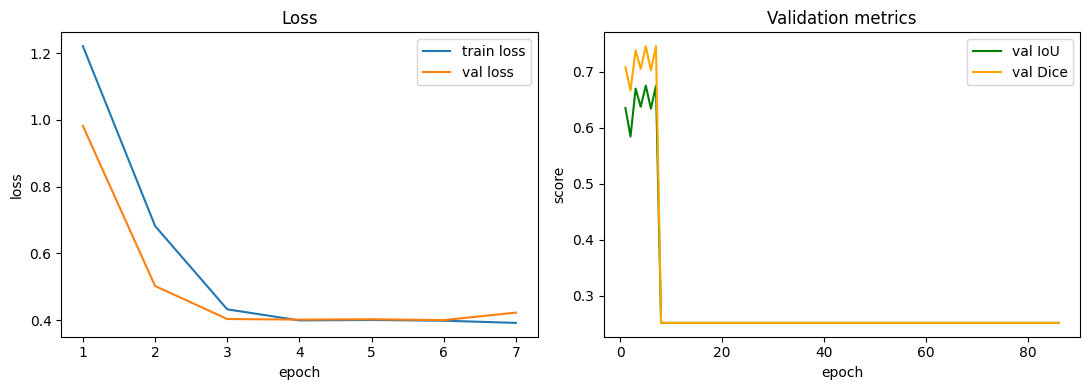

epoch  86 |  50.0 min | train_loss nan | val_loss nan | val_iou 0.2512 | val_dice 0.2512 | best_val_iou 0.6754
stopping: elapsed=50.0 min, epoch=87
training finished. best val IoU: 0.6754


In [13]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
                           pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=60, eta_min=1e-5)
scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

history = {"epoch": [], "train_loss": [], "val_loss": [], "val_iou": [], "val_dice": []}
best_val_iou = -1.0
best_state = None

time_budget_s = TRAIN_TIME_BUDGET_MIN * 60
t_start = time.time()
epoch = 0

def live_plot():
    clear_output(wait=True)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    ax1.plot(history["epoch"], history["train_loss"], label="train loss")
    ax1.plot(history["epoch"], history["val_loss"], label="val loss")
    ax1.set_xlabel("epoch"); ax1.set_ylabel("loss"); ax1.legend(); ax1.set_title("Loss")
    ax2.plot(history["epoch"], history["val_iou"], label="val IoU", color="green")
    ax2.plot(history["epoch"], history["val_dice"], label="val Dice", color="orange")
    ax2.set_xlabel("epoch"); ax2.set_ylabel("score"); ax2.legend(); ax2.set_title("Validation metrics")
    fig.tight_layout()
    plt.show()
    if history["epoch"]:
        e = history["epoch"][-1]
        print(f"epoch {e:3d} | {(time.time()-t_start)/60:5.1f} min | "
              f"train_loss {history['train_loss'][-1]:.4f} | val_loss {history['val_loss'][-1]:.4f} | "
              f"val_iou {history['val_iou'][-1]:.4f} | val_dice {history['val_dice'][-1]:.4f} | "
              f"best_val_iou {best_val_iou:.4f}")

while True:
    epoch += 1
    elapsed = time.time() - t_start
    if elapsed > time_budget_s or epoch > MAX_EPOCHS:
        print(f"stopping: elapsed={elapsed/60:.1f} min, epoch={epoch}")
        break

    model.train()
    running_loss, n_batches = 0.0, 0
    for imgs, msks in train_loader:
        imgs, msks = imgs.to(device, non_blocking=True), msks.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            logits = model(imgs)
            loss = combined_loss(logits, msks)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item(); n_batches += 1
        if time.time() - t_start > time_budget_s:
            break
    train_loss = running_loss / max(n_batches, 1)

    model.eval()
    val_loss_sum = val_iou_sum = val_dice_sum = 0.0
    val_batches = 0
    with torch.no_grad():
        for imgs, msks in val_loader:
            imgs, msks = imgs.to(device, non_blocking=True), msks.to(device, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                logits = model(imgs)
                loss = combined_loss(logits, msks)
            iou, dice, _ = compute_metrics(logits, msks)
            val_loss_sum += loss.item(); val_iou_sum += iou; val_dice_sum += dice
            val_batches += 1
    val_loss = val_loss_sum / max(val_batches, 1)
    val_iou = val_iou_sum / max(val_batches, 1)
    val_dice = val_dice_sum / max(val_batches, 1)
    scheduler.step()

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_iou"].append(val_iou)
    history["val_dice"].append(val_dice)

    if val_iou > best_val_iou:
        best_val_iou = val_iou
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        torch.save(best_state, OUT_DIR / "best_model.pt")

    live_plot()

print(f"training finished. best val IoU: {best_val_iou:.4f}")
if best_state is not None:
    model.load_state_dict(best_state)

## 7. Evaluate on the held-out test set

In [14]:
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

model.eval()
test_iou_sum = test_dice_sum = test_acc_sum = 0.0
test_batches = 0
with torch.no_grad():
    for imgs, msks in test_loader:
        imgs, msks = imgs.to(device, non_blocking=True), msks.to(device, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            logits = model(imgs)
        iou, dice, acc = compute_metrics(logits, msks)
        test_iou_sum += iou; test_dice_sum += dice; test_acc_sum += acc
        test_batches += 1

test_iou = test_iou_sum / max(test_batches, 1)
test_dice = test_dice_sum / max(test_batches, 1)
test_acc = test_acc_sum / max(test_batches, 1)
print(f"TEST  IoU: {test_iou:.4f}   Dice: {test_dice:.4f}   PixelAcc: {test_acc:.4f}")

summary = {
    "n_train": len(train_idx), "n_val": len(val_idx), "n_test": len(test_idx),
    "epochs_trained": epoch - 1, "best_val_iou": best_val_iou,
    "test_iou": test_iou, "test_dice": test_dice, "test_pixel_acc": test_acc,
    "model_params_millions": n_params / 1e6,
}
with open(OUT_DIR / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)
summary


TEST  IoU: 0.6891   Dice: 0.7575   PixelAcc: 0.9984


{'n_train': 13316,
 'n_val': 1664,
 'n_test': 1665,
 'epochs_trained': 86,
 'best_val_iou': 0.6753662985104781,
 'test_iou': 0.6891476357424701,
 'test_dice': 0.7574740184677972,
 'test_pixel_acc': 0.9984013504452176,
 'model_params_millions': 8.903811}

## 8. Visualize test predictions

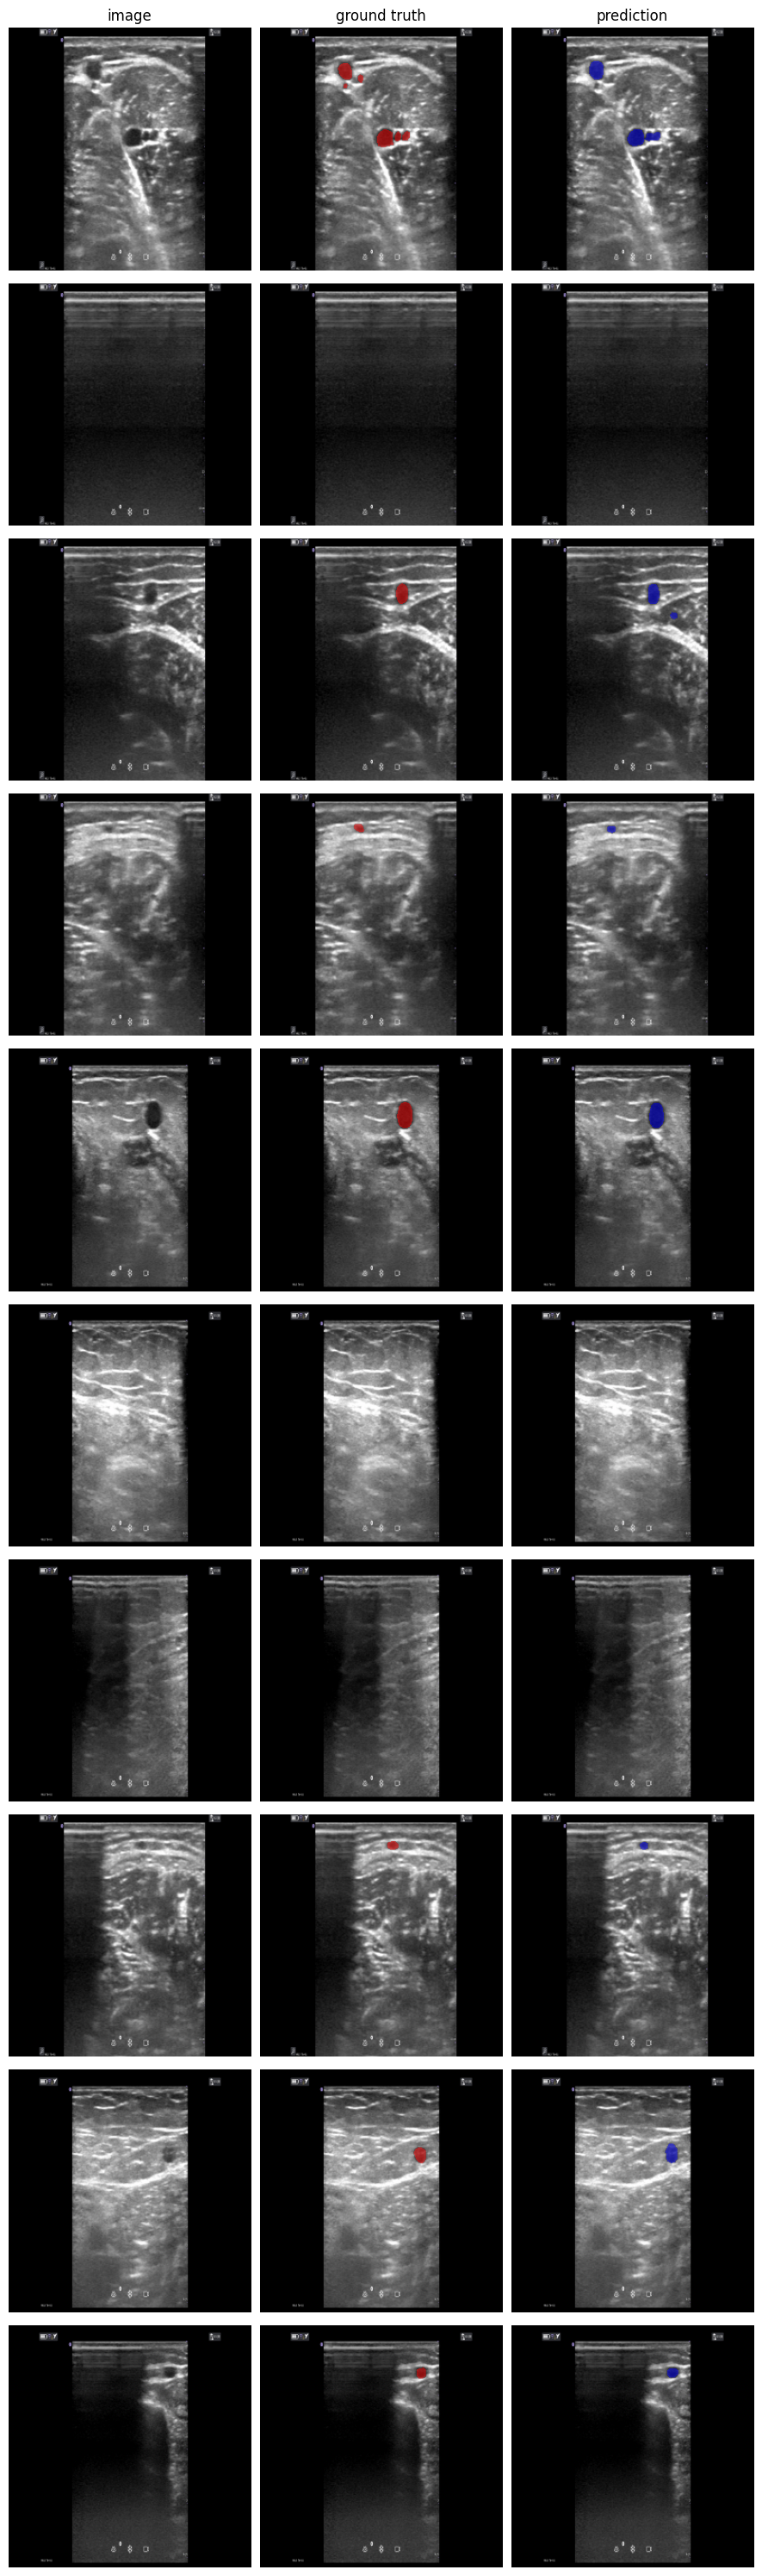

In [15]:
def show_predictions(model, dataset, n=12):
    model.eval()
    idxs = np.random.choice(len(dataset), size=min(n, len(dataset)), replace=False)
    fig, axes = plt.subplots(len(idxs), 3, figsize=(9, 3 * len(idxs)))
    with torch.no_grad():
        for r, i in enumerate(idxs):
            img, mask = dataset[i]
            logits = model(img.unsqueeze(0).to(device))
            pred = (torch.sigmoid(logits) > 0.5).float().cpu().squeeze().numpy()
            im = denorm_img(img)
            gt = mask.squeeze(0).numpy()

            axes[r, 0].imshow(im); axes[r, 0].axis("off")
            axes[r, 1].imshow(im); axes[r, 1].imshow(np.ma.masked_where(gt == 0, gt), cmap="autumn", alpha=0.5); axes[r, 1].axis("off")
            axes[r, 2].imshow(im); axes[r, 2].imshow(np.ma.masked_where(pred == 0, pred), cmap="winter", alpha=0.5); axes[r, 2].axis("off")
            if r == 0:
                axes[r, 0].set_title("image"); axes[r, 1].set_title("ground truth"); axes[r, 2].set_title("prediction")
    fig.tight_layout()
    plt.show()

show_predictions(model, test_ds, n=10)


## 9. Save the trained model

In [ ]:
torch.save(model.state_dict(), OUT_DIR / "final_model.pt")
print("saved to", (OUT_DIR / "final_model.pt").resolve())

saved to C:\Users\Krish\Downloads\Cygnus_Med_Demo\Vein_Annotations\DL_Training\outputs_notebook\final_model.pt
